In [1]:
#导入库
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os
import time
from difflib import get_close_matches
from torch.utils.data import DataLoader, TensorDataset
import random
from collections import defaultdict, deque

In [2]:
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# -------------------- 数据加载与预处理 --------------------
def verify_environment():
    """验证PyTorch环境"""
    print("\n=== 环境验证 ===")
    print(f"PyTorch版本: {torch.__version__}")
    print(f"CUDA可用: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"CUDA版本: {torch.version.cuda}")
        print(f"GPU设备: {torch.cuda.get_device_name(0)}")
    print("================\n")

def load_kg_data(nodes_path, edges_path):
    """加载知识图谱节点和边数据"""
    try:
        print(f"加载节点数据: {nodes_path}")
        nodes = pd.read_csv(nodes_path)
        print(f"加载边数据: {edges_path}")
        edges = pd.read_csv(edges_path)
        print(f"节点数据形状: {nodes.shape}, 边数据形状: {edges.shape}")

        unique_nodes = nodes['node_id'].unique()
        node_id_map = {node_id: idx for idx, node_id in enumerate(unique_nodes)}
        unique_rels = edges['relation_type'].unique()
        rel_id_map = {rel: idx for idx, rel in enumerate(unique_rels)}
        print(f"创建了 {len(rel_id_map)} 个关系映射")

        node_name_map = {}
        name_columns = ['name', 'node_name', 'label', 'description', '中文名', '名称', 'title']
        for col in name_columns:
            if col in nodes.columns:
                print(f"使用列 '{col}' 创建名称映射")
                valid_rows = nodes[pd.notna(nodes[col])]
                for _, row in valid_rows.iterrows():
                    clean_name = str(row[col]).strip().lower()
                    if clean_name and len(clean_name) > 0:
                        node_name_map[clean_name] = row['node_id']
                break

        if not node_name_map:
            print("警告: 未能创建名称映射，使用ID作为名称")
            for node_id in unique_nodes:
                node_name_map[str(node_id).lower()] = node_id
        print(f"创建的节点名称映射数量: {len(node_name_map)}")

        triples = []
        missing_mappings = 0
        for _, row in edges.iterrows():
            head = node_id_map.get(row['source_id'])
            tail = node_id_map.get(row['target_id'])
            rel = rel_id_map.get(row['relation_type'])
            if head is not None and tail is not None and rel is not None:
                triples.append((head, rel, tail))
            else:
                missing_mappings += 1
        print(f"成功创建 {len(triples)} 个三元组，缺失映射: {missing_mappings}")

        return nodes, edges, np.array(triples), node_id_map, node_name_map, rel_id_map
    except Exception as e:
        print(f"数据加载错误: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None, None, None, None

def enhanced_symptom_mapping(nodes_df, common_symptoms):
    """多层症状映射策略"""
    print("\n=== 多层症状映射策略 ===")
    symptom_mapping = {}
    mapping_stats = {'exact': 0, 'keyword': 0, 'semantic': 0, 'virtual': 0, 'failed': 0}

    # 第1层：精确匹配
    for symptom in common_symptoms:
        condition = (
            (nodes_df['node_name'] == symptom) |
            (nodes_df['node_name'].str.contains(symptom, na=False))
        )
        if 'name' in nodes_df.columns:
            condition = condition | (nodes_df['name'] == symptom)

        exact_matches = nodes_df[condition]
        if not exact_matches.empty:
            symptom_mapping[symptom] = exact_matches.iloc[0]['node_id']
            mapping_stats['exact'] += 1
            actual_name = exact_matches.iloc[0].get('node_name', '未知')
            print(f"✅ [精确] '{symptom}' -> '{actual_name}'")
            continue

    # 第2层：关键词匹配
    remaining_symptoms = [s for s in common_symptoms if s not in symptom_mapping]
    if 'node_type' in nodes_df.columns:
        symptom_nodes = nodes_df[nodes_df['node_type'] == 'symptom']
    else:
        symptom_nodes = nodes_df
        print("警告: 没有node_type列，使用所有节点进行关键词匹配")

    for symptom in remaining_symptoms:
        keyword_matches = []
        for _, node in symptom_nodes.iterrows():
            node_name = str(node['node_name']) if pd.notna(node.get('node_name')) else ""
            if symptom in node_name:
                keyword_matches.append(node)
        if keyword_matches:
            best_match = min(keyword_matches,
                             key=lambda x: len(str(x['node_name']) if pd.notna(x.get('node_name')) else 0))
            symptom_mapping[symptom] = best_match['node_id']
            mapping_stats['keyword'] += 1
            actual_name = best_match.get('node_name', '未知')
            print(f"✅ [关键词] '{symptom}' -> '{actual_name}'")
            continue

    # 第3层：语义匹配
    remaining_symptoms = [s for s in common_symptoms if s not in symptom_mapping]
    for symptom in remaining_symptoms:
        best_similarity = 0
        best_node = None
        for _, node in symptom_nodes.iterrows():
            node_name = str(node['node_name']) if pd.notna(node['node_name']) else ""
            common_chars = len(set(symptom) & set(node_name))
            total_chars = len(set(symptom) | set(node_name))
            similarity = common_chars / total_chars if total_chars > 0 else 0
            if similarity > best_similarity and similarity > 0.3:
                best_similarity = similarity
                best_node = node
        if best_node is not None:
            symptom_mapping[symptom] = best_node['node_id']
            mapping_stats['semantic'] += 1
            print(f"✅ [语义] '{symptom}' -> '{best_node['node_name']}' (相似度: {best_similarity:.2f})")

    print(f"\n=== 映射统计 ===")
    for method, count in mapping_stats.items():
        print(f"{method}: {count}")
    success_rate = (len(symptom_mapping) / len(common_symptoms)) * 100
    print(f"总体成功率: {success_rate:.1f}%")
    return symptom_mapping

def comprehensive_data_analysis(nodes, edges, triples, node_id_map):
    """全面的数据分析（仅打印，不返回未使用变量）"""
    print("\n" + "=" * 60)
    print("数据质量分析")
    print("=" * 60)

    print("\n1. 节点类型分布:")
    node_types = nodes['node_type'].value_counts()
    for node_type, count in node_types.items():
        print(f"   {node_type}: {count}")

    print("\n2. 关系类型分布:")
    relation_types = edges['relation_type'].value_counts()
    for rel_type, count in relation_types.items():
        print(f"   {rel_type}: {count}")

    print("\n3. 图结构分析:")
    print(f"   节点数: {len(nodes)}")
    print(f"   边数: {len(edges)}")
    print(f"   三元组数: {len(triples)}")
    print(f"   平均度: {len(edges) / len(nodes):.2f}")

    all_nodes_in_edges = set(edges['source_id']).union(set(edges['target_id']))
    isolated_nodes = set(nodes['node_id']) - all_nodes_in_edges
    print(f"   孤立节点数: {len(isolated_nodes)}")

    print("\n4. 关键中医实体检查:")
    key_entities = ['北柴胡', '脾虚', '湿热', '威灵仙', '头痛', '发热']
    for entity in key_entities:
        found = False
        for name_col in ['name', 'node_name']:
            if name_col in nodes.columns:
                matches = nodes[nodes[name_col].str.contains(entity, na=False)]
                if len(matches) > 0:
                    print(f"   {entity}: 找到 {len(matches)} 个匹配")
                    found = True
                    break
        if not found:
            print(f"   {entity}: 未找到")


In [4]:
# -------------------- 图结构增强 --------------------
def graph_structure_only_augmentation(nodes, edges, node_id_map):
    """仅基于图结构的数据增强"""
    print("开始基于图结构的数据增强...")
    enhanced_edges = edges.copy()

    # 1. 同类型节点连接
    print("1. 同类型节点连接...")
    type_connections = intra_type_connections(nodes, node_id_map)
    enhanced_edges = pd.concat([enhanced_edges, pd.DataFrame(type_connections)], ignore_index=True)
    print(f"   添加了 {len(type_connections)} 个同类型连接")

    # 2. 构建基础诊疗路径
    print("2. 构建基础诊疗路径...")
    treatment_paths = build_treatment_paths_from_data(nodes, edges, node_id_map)
    enhanced_edges = pd.concat([enhanced_edges, pd.DataFrame(treatment_paths)], ignore_index=True)
    print(f"   添加了 {len(treatment_paths)} 个诊疗路径连接")

    # 3. 传递关系挖掘
    print("3. 传递关系挖掘...")
    transitive_relations = mine_transitive_relations(enhanced_edges, node_id_map)
    enhanced_edges = pd.concat([enhanced_edges, pd.DataFrame(transitive_relations)], ignore_index=True)
    print(f"   添加了 {len(transitive_relations)} 个传递关系")

    # 4. 社区检测连接
    print("4. 社区检测连接...")
    community_connections = community_based_connections(nodes, enhanced_edges, node_id_map)
    enhanced_edges = pd.concat([enhanced_edges, pd.DataFrame(community_connections)], ignore_index=True)
    print(f"   添加了 {len(community_connections)} 个社区连接")

    # 去重
    enhanced_edges = deduplicate_edges_simple(enhanced_edges)

    original_edges = len(edges)
    new_edges = len(enhanced_edges)
    print(f"\n增强完成:")
    print(f"- 原边数: {original_edges}")
    print(f"- 新边数: {new_edges}")
    print(f"- 增加边数: {new_edges - original_edges}")
    print(f"- 增长率: {(new_edges - original_edges) / original_edges * 100:.1f}%")

    return enhanced_edges

def intra_type_connections(nodes, node_id_map, max_connections_per_type=500):
    """同类型节点内部连接"""
    connections = []
    type_groups = nodes.groupby('node_type')
    for node_type, group in type_groups:
        node_ids = group['node_id'].tolist()
        valid_ids = [node_id for node_id in node_ids if node_id in node_id_map]
        if len(valid_ids) >= 2:
            connection_count = 0
            for i in range(len(valid_ids)):
                if connection_count >= max_connections_per_type:
                    break
                for j in range(i + 1, min(i + 4, len(valid_ids))):
                    connections.append({
                        'source_id': valid_ids[i],
                        'target_id': valid_ids[j],
                        'relation_type': f'same_{node_type}'
                    })
                    connection_count += 1
                    if connection_count >= max_connections_per_type:
                        break
    return connections

def build_treatment_paths_from_data(nodes, edges, node_id_map):
    """从现有数据构建诊疗路径"""
    connections = []
    relation_patterns = analyze_relation_patterns(edges, nodes)
    for pattern in relation_patterns:
        new_connections = expand_based_on_pattern(pattern, nodes, node_id_map)
        connections.extend(new_connections)

    symptom_nodes = nodes[nodes['node_type'] == 'symptom']['node_id'].tolist()
    syndrome_nodes = nodes[nodes['node_type'] == 'tcm_syndrome']['node_id'].tolist()
    herb_nodes = nodes[nodes['node_type'] == 'herb']['node_id'].tolist()

    max_connections = min(200, len(symptom_nodes), len(syndrome_nodes))
    for i in range(max_connections):
        symptom = symptom_nodes[i % len(symptom_nodes)]
        syndrome = syndrome_nodes[i % len(syndrome_nodes)]
        connections.append({
            'source_id': symptom,
            'target_id': syndrome,
            'relation_type': 'may_indicate'
        })

    max_connections = min(200, len(syndrome_nodes), len(herb_nodes))
    for i in range(max_connections):
        syndrome = syndrome_nodes[i % len(syndrome_nodes)]
        herb = herb_nodes[i % len(herb_nodes)]
        connections.append({
            'source_id': syndrome,
            'target_id': herb,
            'relation_type': 'treated_by'
        })
    return connections

def analyze_relation_patterns(edges, nodes):
    """分析现有的关系模式"""
    from collections import Counter
    edge_with_types = []
    for _, edge in edges.iterrows():
        source_type = get_node_type_by_id(edge['source_id'], nodes)
        target_type = get_node_type_by_id(edge['target_id'], nodes)
        edge_with_types.append({
            'source_type': source_type,
            'target_type': target_type,
            'relation_type': edge['relation_type']
        })
    pattern_counter = Counter()
    for edge in edge_with_types:
        pattern = f"{edge['source_type']}->{edge['target_type']}:{edge['relation_type']}"
        pattern_counter[pattern] += 1
    frequent_patterns = [pattern for pattern, count in pattern_counter.items() if count >= 2]
    return frequent_patterns

def expand_based_on_pattern(pattern, nodes, node_id_map):
    """基于模式扩展关系"""
    connections = []
    try:
        parts = pattern.split(':')
        if len(parts) != 2:
            return connections
        type_part, relation_type = parts
        source_type, target_type = type_part.split('->')
        source_nodes = nodes[nodes['node_type'] == source_type]['node_id'].tolist()
        target_nodes = nodes[nodes['node_type'] == target_type]['node_id'].tolist()
        max_connections = min(50, len(source_nodes), len(target_nodes))
        for i in range(max_connections):
            source = source_nodes[i % len(source_nodes)]
            target = target_nodes[i % len(target_nodes)]
            if source in node_id_map and target in node_id_map:
                connections.append({
                    'source_id': source,
                    'target_id': target,
                    'relation_type': relation_type
                })
    except:
        pass
    return connections

def mine_transitive_relations(edges, node_id_map, max_transitive=1000):
    """挖掘传递关系"""
    connections = []
    adjacency = defaultdict(set)
    for _, edge in edges.iterrows():
        if edge['source_id'] in node_id_map and edge['target_id'] in node_id_map:
            adjacency[edge['source_id']].add(edge['target_id'])
    transitive_count = 0
    for node_a in list(adjacency.keys()):
        if transitive_count >= max_transitive:
            break
        for node_b in adjacency[node_a]:
            for node_c in adjacency[node_b]:
                if (node_a != node_c and
                        node_c not in adjacency[node_a] and
                        transitive_count < max_transitive):
                    connections.append({
                        'source_id': node_a,
                        'target_id': node_c,
                        'relation_type': 'transitive_relation'
                    })
                    transitive_count += 1
    return connections

def community_based_connections(nodes, edges, node_id_map):
    """基于社区检测的连接"""
    connections = []
    try:
        import networkx as nx
        G = nx.Graph()
        for _, node in nodes.iterrows():
            G.add_node(node['node_id'])
        for _, edge in edges.iterrows():
            if (edge['source_id'] in node_id_map and
                    edge['target_id'] in node_id_map):
                G.add_edge(edge['source_id'], edge['target_id'])
        communities = list(nx.connected_components(G))
        for community in communities:
            community_nodes = list(community)
            if len(community_nodes) > 1:
                for i in range(min(10, len(community_nodes))):
                    node1 = random.choice(community_nodes)
                    node2 = random.choice(community_nodes)
                    if node1 != node2 and not G.has_edge(node1, node2):
                        connections.append({
                            'source_id': node1,
                            'target_id': node2,
                            'relation_type': 'intra_community'
                        })
        if len(communities) > 1:
            for i in range(min(20, len(communities))):
                comm1 = random.choice(communities)
                comm2 = random.choice(communities)
                if comm1 != comm2:
                    node1 = random.choice(list(comm1))
                    node2 = random.choice(list(comm2))
                    connections.append({
                        'source_id': node1,
                        'target_id': node2,
                        'relation_type': 'inter_community_bridge'
                    })
    except ImportError:
        print("NetworkX不可用，跳过社区检测")
    return connections

def deduplicate_edges_simple(edges):
    """简单去重"""
    unique_edges = set()
    deduplicated = []
    for _, edge in edges.iterrows():
        edge_key = (edge['source_id'], edge['target_id'], edge['relation_type'])
        if edge_key not in unique_edges:
            unique_edges.add(edge_key)
            deduplicated.append(edge)
    return pd.DataFrame(deduplicated)

def get_node_type_by_id(node_id, nodes):
    """根据节点ID获取类型"""
    node_info = nodes[nodes['node_id'] == node_id]
    if not node_info.empty:
        return node_info.iloc[0].get('node_type', 'unknown')
    return 'unknown'


In [5]:
# -------------------- TransE 模型 --------------------
class TransE(nn.Module):
    def __init__(self, num_entities, num_relations, embedding_dim=100, norm=2):
        super(TransE, self).__init__()
        self.num_entities = num_entities
        self.num_relations = num_relations
        self.embedding_dim = embedding_dim
        self.norm = norm
        self.entity_emb = nn.Embedding(num_entities, embedding_dim)
        self.relation_emb = nn.Embedding(num_relations, embedding_dim)
        self._initialize_embeddings()

    def _initialize_embeddings(self):
        nn.init.uniform_(self.entity_emb.weight, a=-0.01, b=0.01)
        nn.init.uniform_(self.relation_emb.weight, a=-0.005, b=0.005)
        with torch.no_grad():
            entity_norms = torch.norm(self.entity_emb.weight, p=2, dim=1, keepdim=True)
            self.entity_emb.weight.data = self.entity_emb.weight.data / torch.clamp(entity_norms, min=1e-8)
            relation_norms = torch.norm(self.relation_emb.weight, p=2, dim=1, keepdim=True)
            self.relation_emb.weight.data = self.relation_emb.weight.data / torch.clamp(relation_norms, min=1e-8)

    def forward(self, head, relation, tail):
        h = self.entity_emb(head)
        r = self.relation_emb(relation)
        t = self.entity_emb(tail)
        score = torch.norm(h + r - t, p=2, dim=1)
        return -score

# -------------------- 注意力GNN --------------------
from torch_geometric.nn import GATConv

class AttentionGNN(nn.Module):
    def __init__(self, num_entities, num_relations, embedding_dim=100):
        super(AttentionGNN, self).__init__()
        self.num_entities = num_entities
        self.num_relations = num_relations
        self.entity_emb = nn.Embedding(num_entities, embedding_dim)
        self.relation_emb = nn.Embedding(num_relations, embedding_dim)
        self.gat = GATConv(embedding_dim, embedding_dim // 2, heads=4, concat=True, dropout=0.1)
        self.output_proj = nn.Linear(embedding_dim * 2, embedding_dim)
        self.residual_weight = nn.Parameter(torch.tensor(0.5))
        self._initialize_weights()

    def _initialize_weights(self):
        nn.init.uniform_(self.entity_emb.weight, a=-0.01, b=0.01)
        nn.init.uniform_(self.relation_emb.weight, a=-0.01, b=0.01)
        nn.init.constant_(self.residual_weight, 0.5)

    def build_graph_from_triples(self, triples, device, max_edges=8000):
        if len(triples) == 0:
            return None, None, None
        if len(triples) > max_edges:
            indices = torch.randperm(len(triples))[:max_edges]
            triples = [triples[i] for i in indices]
            print(f"图构建: 从 {len(triples)} 个三元组中采样 {max_edges} 个")
        triples_tensor = torch.LongTensor(triples).to(device)
        head_indices = triples_tensor[:, 0]
        tail_indices = triples_tensor[:, 2]
        edge_index = torch.stack([
            torch.cat([head_indices, tail_indices]),
            torch.cat([tail_indices, head_indices])
        ], dim=0)
        relation_types = torch.cat([triples_tensor[:, 1], triples_tensor[:, 1]])
        return edge_index, relation_types, relation_types

    def forward(self, entity_indices, edge_index, relation_types, edge_attr=None):
        x = self.entity_emb(entity_indices)
        original_x = x.clone()
        if edge_index is not None and edge_index.size(1) > 0:
            try:
                x_gat = F.elu(self.gat(x, edge_index))
                x_gat = F.dropout(x_gat, p=0.1, training=self.training)
                x_gat_proj = self.output_proj(x_gat)
                residual_weight = torch.sigmoid(self.residual_weight)
                x = residual_weight * x_gat_proj + (1 - residual_weight) * original_x
            except Exception as e:
                print(f"GAT前向传播失败: {str(e)}，使用原始嵌入")
                x = original_x
        return x

    def compute_triple_score(self, head, relation, tail, entity_embeddings):
        try:
            min_len = min(len(head), len(relation), len(tail))
            if min_len == 0:
                return torch.tensor([0.0], device=head.device)
            head = head[:min_len]
            relation = relation[:min_len]
            tail = tail[:min_len]
            h = entity_embeddings[head]
            r = self.relation_emb(relation)
            t = entity_embeddings[tail]
            score = torch.norm(h + r - t, p=2, dim=1)
            return -score
        except Exception as e:
            print(f"三元组评分错误: {str(e)}")
            min_len = min(len(head), len(relation), len(tail))
            return torch.zeros(min_len, device=head.device if head.numel() > 0 else 'cpu')

    def get_residual_weight(self):
        return torch.sigmoid(self.residual_weight).item()

# -------------------- 中医诊断环境 --------------------
class TCMDiagnosticEnv:
    def __init__(self, kg_model, node_id_map, nodes_df, edges_df, symptom_mapping=None, max_steps=12):
        self.kg_model = kg_model
        self.node_id_map = node_id_map
        self.nodes_df = nodes_df
        self.edges_df = edges_df
        self.symptom_mapping = symptom_mapping if symptom_mapping is not None else {}
        self.max_steps = max_steps
        self.idx_to_node = {idx: node_id for node_id, idx in node_id_map.items()}
        self.node_to_idx = node_id_map
        self.graph_structure = self._build_knowledge_graph()
        self.reset()

    def _build_knowledge_graph(self):
        print("构建知识图谱结构...")
        graph = defaultdict(list)
        relation_strengths = defaultdict(float)
        relation_count = 0
        for _, edge in self.edges_df.iterrows():
            source_idx = self.node_id_map.get(edge['source_id'])
            target_idx = self.node_id_map.get(edge['target_id'])
            if source_idx is not None and target_idx is not None:
                rel_type = edge['relation_type']
                graph[source_idx].append((target_idx, rel_type))
                relation_strengths[rel_type] += 1.0
                relation_count += 1
        if relation_count > 0:
            for rel_type in relation_strengths:
                relation_strengths[rel_type] /= relation_count
        print(f"图谱构建完成: {relation_count} 条关系，{len(graph)} 个节点有出边")
        return {'adjacency': graph, 'relation_strengths': relation_strengths}

    def reset(self):
        self.current_step = 0
        self.current_state = self._select_initial_state()
        self.diagnosis_path = [self.current_state]
        self.path_types = [self._get_node_type(self.current_state)]
        self.done = False
        self.successful = False
        return self._get_state_representation()

    def _select_initial_state(self):
        symptom_nodes = self.nodes_df[self.nodes_df['node_type'] == 'symptom']
        candidate_states = []
        for _, symptom in symptom_nodes.iterrows():
            node_id = symptom['node_id']
            if node_id in self.node_id_map:
                idx = self.node_id_map[node_id]
                if idx in self.graph_structure['adjacency']:
                    candidate_states.append(idx)
        if candidate_states:
            return random.choice(candidate_states)
        else:
            if len(symptom_nodes) > 0:
                start_symptom = symptom_nodes.sample(1).iloc[0]
                return self.node_id_map.get(start_symptom['node_id'], 0)
            return 0

    def _get_state_representation(self):
        if isinstance(self.current_state, str):
            if self.current_state in self.node_id_map:
                self.current_state = self.node_id_map[self.current_state]
            else:
                self.current_state = 0
        entity_tensor = torch.tensor([self.current_state], device='cpu')
        with torch.no_grad():
            current_embedding = self.kg_model.entity_emb(entity_tensor).squeeze().numpy()
        path_length = len(self.diagnosis_path)
        step_ratio = self.current_step / self.max_steps
        current_type = self._get_node_type(self.current_state)
        goal_progress = self._calculate_goal_progress(current_type)
        state_representation = np.concatenate([
            current_embedding,
            np.array([path_length, step_ratio, goal_progress])
        ])
        return state_representation

    def _calculate_goal_progress(self, current_type):
        if current_type == 'herb':
            return 1.0
        elif current_type == 'tcm_syndrome':
            return 0.7
        elif current_type == 'symptom':
            return 0.3
        else:
            return 0.1

    def _get_node_type(self, state_idx):
        if isinstance(state_idx, str):
            node_info = self.nodes_df[self.nodes_df['node_id'] == state_idx]
        else:
            if state_idx in self.idx_to_node:
                node_id = self.idx_to_node[state_idx]
                node_info = self.nodes_df[self.nodes_df['node_id'] == node_id]
            else:
                return 'unknown'
        if not node_info.empty:
            return node_info.iloc[0].get('node_type', 'unknown')
        return 'unknown'

    def get_available_actions(self):
        available_actions = []
        if self.current_state in self.graph_structure['adjacency']:
            neighbors = self.graph_structure['adjacency'][self.current_state]
            for neighbor_idx, rel_type in neighbors:
                available_actions.append(neighbor_idx)
        semantic_actions = self._get_semantic_actions()
        available_actions.extend(semantic_actions)
        if len(available_actions) < 3:
            all_entities = list(self.node_id_map.values())
            additional_actions = random.sample(all_entities, min(5, len(all_entities)))
            available_actions.extend(additional_actions)
        available_actions = list(set(available_actions))
        return available_actions[:10]

    def _get_semantic_actions(self):
        current_type = self._get_node_type(self.current_state)
        semantic_actions = []
        if current_type == 'symptom':
            target_type = 'tcm_syndrome'
        elif current_type == 'tcm_syndrome':
            target_type = 'herb'
        else:
            target_type = None
        if target_type:
            target_nodes = self.nodes_df[self.nodes_df['node_type'] == target_type]
            for _, node in target_nodes.iterrows():
                node_id = node['node_id']
                if node_id in self.node_id_map:
                    semantic_actions.append(self.node_id_map[node_id])
        return semantic_actions[:5]

    def map_symptom_to_node(self, symptom_name):
        if symptom_name in self.symptom_mapping:
            node_id = self.symptom_mapping[symptom_name]
            return self.node_id_map.get(node_id)
        return None

    def set_initial_symptoms(self, symptom_names):
        symptom_indices = []
        for symptom in symptom_names:
            node_idx = self.map_symptom_to_node(symptom)
            if node_idx is not None:
                symptom_indices.append(node_idx)
                node_id = self.idx_to_node[node_idx]
                node_info = self.nodes_df[self.nodes_df['node_id'] == node_id]
                if not node_info.empty:
                    actual_name = node_info.iloc[0].get('node_name', '未知')
                    print(f"✅ 映射症状: '{symptom}' -> '{actual_name}' (索引: {node_idx})")
            else:
                print(f"❌ 无法映射症状: '{symptom}'")
        if symptom_indices:
            self.current_state = symptom_indices[0]
            self.diagnosis_path = [self.current_state]
            return True
        else:
            print("⚠️ 未找到任何初始症状，使用随机初始状态")
            return False

    def step(self, action):
        self.current_step += 1
        if isinstance(action, str):
            if action in self.node_id_map:
                action = self.node_id_map[action]
            else:
                action = random.choice(list(self.node_id_map.values()))
        elif not isinstance(action, int):
            try:
                action = int(action)
            except:
                action = random.choice(list(self.node_id_map.values()))
        prev_state = self.current_state
        self.current_state = action
        self.diagnosis_path.append(action)
        self.path_types.append(self._get_node_type(action))

        reward = self._compute_advanced_reward(prev_state, action)
        self.done = self._check_termination()
        next_state = self._get_state_representation()
        return next_state, reward, self.done, {
            'path_length': len(self.diagnosis_path),
            'success': self.successful,
            'final_type': self._get_node_type(action)
        }

    def _compute_advanced_reward(self, prev_state, action):
        reward = 0.0
        prev_type = self._get_node_type(prev_state)
        current_type = self._get_node_type(action)

        path_bonus = self._calculate_path_bonus(prev_type, current_type)
        reward += path_bonus

        if current_type == 'herb':
            reward += 5.0
            self.successful = True
        elif current_type == 'tcm_syndrome':
            reward += 2.5

        if self._is_valid_transition(prev_state, action):
            reward += 0.8

        diversity_bonus = self._calculate_diversity_bonus(action)
        reward += diversity_bonus

        efficiency_bonus = self._calculate_efficiency_bonus()
        reward += efficiency_bonus

        if self.diagnosis_path.count(action) > 1:
            reward -= 0.3

        return max(reward, -1.0)

    def _calculate_diversity_bonus(self, action):
        current_type = self._get_node_type(action)
        visited_types = set(self.path_types)
        if current_type not in visited_types:
            return 0.5
        elif len(visited_types) < 3:
            return 0.2
        else:
            return 0.0

    def _calculate_efficiency_bonus(self):
        if self.successful:
            optimal_length = 3
            actual_length = len(self.diagnosis_path)
            if actual_length <= optimal_length:
                return 3.0
            else:
                return max(0, (optimal_length * 2 - actual_length) * 0.3)
        return 0.0

    def _calculate_path_bonus(self, prev_type, current_type):
        transition_bonus = {
            ('symptom', 'tcm_syndrome'): 0.6,
            ('tcm_syndrome', 'herb'): 0.8,
            ('symptom', 'herb'): 0.4,
            ('tcm_syndrome', 'tcm_syndrome'): 0.1,
            ('herb', 'herb'): -0.3,
        }
        return transition_bonus.get((prev_type, current_type), 0.0)

    def _is_valid_transition(self, prev_state, action):
        if prev_state in self.graph_structure['adjacency']:
            neighbors = [neighbor for neighbor, _ in self.graph_structure['adjacency'][prev_state]]
            return action in neighbors
        return False

    def _check_termination(self):
        if self.current_step >= self.max_steps:
            return True
        if self.successful:
            return True
        if len(self.get_available_actions()) == 0:
            return True
        return False

# -------------------- 强化学习智能体 --------------------
class Agent:
    def __init__(self, state_dim, action_dim, learning_rate=0.001):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.q_network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.q_network.to(self.device)
        self.memory = deque(maxlen=10000)
        self.batch_size = 64
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.992
        self.steps = 0
        self.reward_history = []
        self.total_episodes = 0
        self.successful_episodes = 0
        self.best_reward = -float('inf')

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
        self.steps += 1
        self.reward_history.append(reward)
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay
        if reward > 2.0:
            self.epsilon = max(self.epsilon * 0.95, self.epsilon_min)

    def act(self, state, available_actions):
        if not available_actions:
            return random.randint(0, self.action_dim - 1)
        if random.random() <= self.epsilon:
            return random.choice(available_actions)
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            q_values = self.q_network(state_tensor).detach().cpu().numpy()[0]
            available_q_values = [(action, q_values[action]) for action in available_actions]
            return max(available_q_values, key=lambda x: x[1])[0]

    def replay(self):
        if len(self.memory) < self.batch_size:
            return 0.0
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.BoolTensor(dones).to(self.device)

        current_q = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze()
        with torch.no_grad():
            next_q = self.q_network(next_states).max(1)[0]
            target_q = rewards + (0.95 * next_q * ~dones)
        loss = F.mse_loss(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.item()

    def record_episode_completion(self, success=False, total_reward=0):
        self.total_episodes += 1
        if success:
            self.successful_episodes += 1
        if self.total_episodes % 10 == 0 and self.epsilon > self.epsilon_min:
            decay_factor = 0.85 if success else 0.9
            self.epsilon = max(self.epsilon * decay_factor, self.epsilon_min)
            print(f"Episode {self.total_episodes}: Epsilon衰减到 {self.epsilon:.4f} (成功: {success})")
        if total_reward > self.best_reward:
            self.best_reward = total_reward
            if self.epsilon > self.epsilon_min:
                self.epsilon = max(self.epsilon * 0.9, self.epsilon_min)
                print(f"新最佳奖励 {total_reward:.2f}: Epsilon奖励衰减到 {self.epsilon:.4f}")

    def save(self, filepath):
        checkpoint = {
            'q_network_state_dict': self.q_network.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'epsilon': self.epsilon,
            'steps': self.steps,
            'total_episodes': self.total_episodes,
            'successful_episodes': self.successful_episodes,
            'best_reward': self.best_reward,
            'state_dim': self.state_dim,
            'action_dim': self.action_dim
        }
        torch.save(checkpoint, filepath)
        print(f"Agent已保存到: {filepath}")

# -------------------- 集成框架 --------------------
class IntegratedAttentionRLFramework:
    def __init__(self, num_entities, num_relations, embedding_dim=100):
        self.num_entities = num_entities
        self.num_relations = num_relations
        self.embedding_dim = embedding_dim
        self.attention_gnn = AttentionGNN(num_entities, num_relations, embedding_dim)
        self.rl_agent = Agent(state_dim=embedding_dim + 3, action_dim=num_entities, learning_rate=0.001)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.attention_gnn.to(self.device)

    def _clean_memory(self):
        import gc
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    def phased_training(self, train_triples, nodes_df, edges_df, node_id_map):
        print("开始分阶段训练...")
        print("\n=== 阶段1: 增强TransE基础训练 ===")
        self._pretrain_transe_phase(train_triples, num_epochs=60)
        print("\n=== 阶段2: 稳定GNN微调训练 ===")
        self._finetune_gnn_phase(train_triples, num_epochs=50)
        print("\n=== 阶段3: 有效RL策略学习 ===")
        self._train_rl_phase(nodes_df, edges_df, node_id_map, num_episodes=500)
        print("改进的分阶段训练完成!")

    def _pretrain_transe_phase(self, train_triples, num_epochs=50):
        print("安全TransE预训练...")
        transe_model = TransE(self.num_entities, self.num_relations, self.embedding_dim)
        transe_model.to(self.device)
        optimizer = optim.AdamW(transe_model.parameters(), lr=0.001, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
        batch_size = 256
        best_loss = float('inf')
        patience = 10
        patience_counter = 0

        for epoch in range(num_epochs):
            transe_model.train()
            total_loss = 0
            batch_count = 0
            shuffled_indices = torch.randperm(len(train_triples))
            for i in range(0, len(train_triples), batch_size):
                if batch_count % 10 == 0:
                    self._clean_memory()
                batch_indices = shuffled_indices[i:i + batch_size]
                batch_triples = [train_triples[idx] for idx in batch_indices]
                batch_tensor = torch.LongTensor(batch_triples).to(self.device)
                heads, relations, tails = batch_tensor[:, 0], batch_tensor[:, 1], batch_tensor[:, 2]
                pos_scores = transe_model(heads, relations, tails)

                # 改进负采样
                neg_heads = heads.clone()
                neg_tails = tails.clone()
                mask = torch.rand(heads.size(0), device=self.device) < 0.5
                neg_heads[mask] = torch.randint(0, self.num_entities, (mask.sum(),), device=self.device)
                neg_tails[~mask] = torch.randint(0, self.num_entities, ((~mask).sum(),), device=self.device)
                neg_scores = transe_model(neg_heads, relations, neg_tails)

                loss = F.margin_ranking_loss(
                    pos_scores, neg_scores,
                    torch.ones_like(pos_scores),
                    margin=3.0
                )
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(transe_model.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += loss.item()
                batch_count += 1

            avg_loss = total_loss / batch_count
            if avg_loss < best_loss:
                best_loss = avg_loss
                patience_counter = 0
                best_weights = {
                    'entity_emb': transe_model.entity_emb.weight.data.clone(),
                    'relation_emb': transe_model.relation_emb.weight.data.clone()
                }
            else:
                patience_counter += 1
            if patience_counter >= patience:
                print(f"早停在epoch {epoch + 1}, 最佳损失: {best_loss:.4f}")
                break
            scheduler.step()
            if (epoch + 1) % 20 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(f"TransE Epoch {epoch + 1}/{num_epochs}: Loss: {avg_loss:.4f}, LR: {current_lr:.6f}")

        with torch.no_grad():
            self.attention_gnn.entity_emb.weight.data = best_weights['entity_emb']
            self.attention_gnn.relation_emb.weight.data = best_weights['relation_emb']
        print("增强TransE预训练完成")

    def _finetune_gnn_phase(self, train_triples, num_epochs=30):
        print("GNN微调阶段...")
        self.attention_gnn.train()
        optimizer = optim.AdamW(
            self.attention_gnn.parameters(),
            lr=0.0001,
            weight_decay=1e-4,
            betas=(0.9, 0.999)
        )
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=5, factor=0.5, verbose=True
        )
        edge_index, relation_types, edge_attr = self.attention_gnn.build_graph_from_triples(
            train_triples, self.device, max_edges=5000
        )
        if edge_index is None:
            print("无法构建图结构，跳过GNN训练")
            return
        entity_indices = torch.arange(self.num_entities).to(self.device)
        best_loss = float('inf')
        patience = 8
        patience_counter = 0
        batch_size = 128

        for epoch in range(num_epochs):
            self.attention_gnn.train()
            total_loss = 0.0
            batch_count = 0
            shuffled_indices = torch.randperm(len(train_triples))
            for i in range(0, len(train_triples), batch_size):
                if batch_count % 5 == 0:
                    self._clean_memory()
                try:
                    batch_indices = shuffled_indices[i:i + batch_size]
                    batch_triples = [train_triples[idx] for idx in batch_indices]
                    current_batch_size = len(batch_triples)
                    if current_batch_size < 2:
                        continue
                    batch_tensor = torch.LongTensor(batch_triples).to(self.device)
                    heads, relations, tails = batch_tensor[:, 0], batch_tensor[:, 1], batch_tensor[:, 2]
                    entity_embeddings = self.attention_gnn(entity_indices, edge_index, relation_types)
                    pos_scores = self.attention_gnn.compute_triple_score(heads, relations, tails, entity_embeddings)
                    neg_heads = torch.randint(0, self.num_entities, (128,), device=self.device)
                    neg_scores = self.attention_gnn.compute_triple_score(
                        neg_heads, relations[:128], tails[:128], entity_embeddings
                    )
                    if len(pos_scores) >= 128:
                        main_loss = F.margin_ranking_loss(
                            pos_scores[:128], neg_scores,
                            torch.ones(128, device=self.device),
                            margin=2.0
                        )
                    else:
                        continue
                    optimizer.zero_grad()
                    main_loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.attention_gnn.parameters(), max_norm=0.5)
                    optimizer.step()
                    total_loss += main_loss.item()
                    batch_count += 1
                except Exception as e:
                    continue
            if batch_count > 0:
                avg_loss = total_loss / batch_count
                if avg_loss < best_loss:
                    best_loss = avg_loss
                    patience_counter = 0
                else:
                    patience_counter += 1
                if patience_counter >= patience:
                    print(f"GNN早停在epoch {epoch + 1}, 最佳损失: {best_loss:.4f}")
                    break
                scheduler.step(avg_loss)
                if (epoch + 1) % 10 == 0:
                    current_lr = optimizer.param_groups[0]['lr']
                    print(f"GNN Epoch {epoch + 1}/{num_epochs}: Loss: {avg_loss:.4f}, LR: {current_lr:.6f}")
        print("稳定GNN微调完成")

    def _train_rl_phase(self, nodes_df, edges_df, node_id_map, num_episodes=300):
        print("稳定RL训练...")
        try:
            self.rl_agent.epsilon = 1.0
            self.rl_agent.steps = 0
            self.rl_agent.total_episodes = 0
            self.rl_agent.successful_episodes = 0

            curriculum_stages = [
                {'max_steps': 12, 'episodes': 100, 'name': '密集探索', 'target_epsilon': 0.8},
                {'max_steps': 10, 'episodes': 100, 'name': '平衡学习', 'target_epsilon': 0.5},
                {'max_steps': 8, 'episodes': 100, 'name': '策略优化', 'target_epsilon': 0.3},
                {'max_steps': 6, 'episodes': 100, 'name': '精细利用', 'target_epsilon': 0.1}
            ]

            for stage_idx, stage in enumerate(curriculum_stages):
                print(f"\n--- {stage['name']} (目标epsilon: {stage['target_epsilon']}) ---")
                env = TCMDiagnosticEnv(
                    self.attention_gnn, node_id_map, nodes_df, edges_df,
                    max_steps=stage['max_steps']
                )
                stage_rewards = []
                stage_successes = []
                stage_epsilons = []

                for episode in range(stage['episodes']):
                    state = env.reset()
                    total_reward = 0
                    done = False
                    steps = 0
                    while not done and steps < stage['max_steps']:
                        available_actions = env.get_available_actions()
                        if not available_actions:
                            break
                        action = self.rl_agent.act(state, available_actions)
                        next_state, reward, done, info = env.step(action)
                        self.rl_agent.remember(state, action, reward, next_state, done)
                        state = next_state
                        total_reward += reward
                        steps += 1

                    replay_losses = []
                    for _ in range(2):
                        loss = self.rl_agent.replay()
                        if loss > 0:
                            replay_losses.append(loss)

                    success = info.get('success', False)
                    self.rl_agent.record_episode_completion(success=success, total_reward=total_reward)
                    stage_rewards.append(total_reward)
                    stage_successes.append(1 if success else 0)
                    stage_epsilons.append(self.rl_agent.epsilon)

                    if episode % 10 == 0 and self.rl_agent.epsilon > stage['target_epsilon']:
                        self.rl_agent.epsilon = max(self.rl_agent.epsilon * 0.95, stage['target_epsilon'])
                        print(f"Episode {episode}: 强制Epsilon衰减到 {self.rl_agent.epsilon:.4f}")

                    if (episode + 1) % 25 == 0:
                        avg_reward = np.mean(stage_rewards[-25:])
                        success_rate = np.mean(stage_successes[-25:]) * 100
                        avg_epsilon = np.mean(stage_epsilons[-25:])
                        avg_loss = np.mean(replay_losses) if replay_losses else 0
                        print(f"Episode {episode + 1}: 奖励: {avg_reward:.2f}, 成功率: {success_rate:.1f}%, Epsilon: {avg_epsilon:.3f}, 损失: {avg_loss:.4f}")

                avg_reward = np.mean(stage_rewards)
                success_rate = np.mean(stage_successes) * 100
                final_epsilon = self.rl_agent.epsilon
                print(f"{stage['name']}完成: 平均奖励 {avg_reward:.2f}, 成功率 {success_rate:.1f}%, 最终Epsilon: {final_epsilon:.3f}")
            print(f"改进RL训练完成，最终Epsilon: {self.rl_agent.epsilon:.3f}")
        except Exception as e:
            print(f"改进RL训练失败: {str(e)}")
            import traceback
            traceback.print_exc()

    def optimize_diagnostic_path(self, initial_symptoms, nodes_df, edges_df, node_id_map, max_steps=8):
        print("优化诊断路径...")
        env = TCMDiagnosticEnv(
            kg_model=self.attention_gnn,
            node_id_map=node_id_map,
            nodes_df=nodes_df,
            edges_df=edges_df,
            symptom_mapping={},
            max_steps=max_steps
        )

        symptom_indices = []
        mapped_symptoms = []
        for symptom in initial_symptoms:
            found = False
            for _, node in nodes_df.iterrows():
                node_name = str(node.get('node_name', ''))
                if symptom in node_name and node['node_id'] in node_id_map:
                    node_idx = node_id_map[node['node_id']]
                    symptom_indices.append(node_idx)
                    mapped_symptoms.append(f"'{symptom}' -> '{node_name}'")
                    found = True
                    break
            if not found:
                print(f"❌ 无法找到症状: '{symptom}'")

        if symptom_indices:
            env.current_state = symptom_indices[0]
            env.diagnosis_path = [env.current_state]
            print(f"✅ 找到初始症状: {', '.join(mapped_symptoms)}")
        else:
            print("⚠️ 未找到任何初始症状，使用随机初始状态")

        return self._execute_diagnostic_path(env, nodes_df, max_steps)

    def _execute_diagnostic_path(self, env, nodes_df, max_steps):
        state = env._get_state_representation()
        total_reward = 0
        done = False
        step = 0
        path_details = []
        print("\n诊断路径:")
        while not done and step < max_steps:
            available_actions = env.get_available_actions()
            if not available_actions:
                print("无可用动作，终止诊断")
                break
            action = self.rl_agent.act(state, available_actions)
            step_info = self._get_step_info(env, action, nodes_df, step)
            path_details.append(step_info)
            print(step_info)
            next_state, reward, done, info = env.step(action)
            state = next_state
            total_reward += reward
            step += 1

        self._show_diagnosis_result(info, path_details, total_reward, env)
        return env.diagnosis_path

    def _get_step_info(self, env, action, nodes_df, step):
        if action in env.idx_to_node:
            action_entity_id = env.idx_to_node[action]
            action_info = nodes_df[nodes_df['node_id'] == action_entity_id]
            if not action_info.empty:
                entity_name = action_info.iloc[0].get('node_name', '未知')
                entity_type = action_info.iloc[0].get('node_type', '未知')
                return f"步骤 {step + 1}: {entity_name} (类型: {entity_type})"
        return f"步骤 {step + 1}: 未知实体 (索引: {action})"

    def _show_diagnosis_result(self, info, path_details, total_reward, env):
        final_type = info.get('final_type', '未知')
        success = info.get('success', False)
        print(f"\n=== 诊断结果分析 ===")
        print(f"路径: {' → '.join([detail.split(': ')[1] for detail in path_details])}")
        print(f"总奖励: {total_reward:.2f}")
        print(f"路径长度: {len(env.diagnosis_path)} 步")
        if success:
            print("✅ 诊断成功: 到达治疗方案")
        else:
            print(f"⚠️ 诊断未完成 (最终类型: {final_type})")

    def save_models(self, gnn_path, rl_path):
        torch.save({
            'gnn_state_dict': self.attention_gnn.state_dict(),
            'gnn_config': {
                'num_entities': self.num_entities,
                'num_relations': self.num_relations,
                'embedding_dim': self.embedding_dim
            }
        }, gnn_path)
        self.rl_agent.save(rl_path)
        print(f"模型已保存: {gnn_path}, {rl_path}")

# -------------------- 训练与评估函数 --------------------
def train_transe_model(model, train_triples, device, node_id_map, node_name_map, nodes_df,
                       num_epochs=300, batch_size=1024, lr=0.01, margin=1.0):
    """使用DataLoader的训练函数 - 内部定义负采样"""
    def _semantic_negative_sampling(heads, tails, num_entities, device, corruption_rate=0.8):
        batch_size = heads.size(0)
        neg_heads = heads.clone()
        neg_tails = tails.clone()
        for i in range(batch_size):
            if torch.rand(1).item() < corruption_rate:
                neg_heads[i] = torch.randint(0, num_entities, (1,), device=device)
            else:
                neg_tails[i] = torch.randint(0, num_entities, (1,), device=device)
        return neg_heads, neg_tails

    train_tensor = torch.LongTensor(train_triples)
    dataset = TensorDataset(train_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model.to(device)
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    loss_history = []
    embedding_norms_history = []

    print(f"开始鲁棒训练，共{num_epochs}个epoch")
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        for batch in dataloader:
            batch_triples = batch[0].to(device)
            heads, relations, tails = batch_triples[:, 0], batch_triples[:, 1], batch_triples[:, 2]
            neg_heads, neg_tails = _semantic_negative_sampling(
                heads, tails, model.num_entities, device, corruption_rate=0.8
            )
            pos_scores = model(heads, relations, tails)
            neg_scores = model(neg_heads, relations, neg_tails)
            loss = F.margin_ranking_loss(
                pos_scores, neg_scores,
                torch.ones_like(pos_scores),
                margin=margin
            )
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        with torch.no_grad():
            entity_norms = torch.norm(model.entity_emb.weight, p=2, dim=1, keepdim=True)
            model.entity_emb.weight.data = model.entity_emb.weight.data / torch.clamp(entity_norms, min=1e-8)
            relation_norms = torch.norm(model.relation_emb.weight, p=2, dim=1, keepdim=True)
            model.relation_emb.weight.data = model.relation_emb.weight.data / torch.clamp(relation_norms, min=1e-8)

        avg_loss = epoch_loss / len(dataloader)
        loss_history.append(avg_loss)
        with torch.no_grad():
            avg_entity_norm = torch.mean(torch.norm(model.entity_emb.weight, p=2, dim=1)).item()
            embedding_norms_history.append(avg_entity_norm)
        scheduler.step()
        if (epoch + 1) % 50 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}, LR: {current_lr:.6f}, Avg Entity Norm: {avg_entity_norm:.4f}")
    return model, loss_history, embedding_norms_history

def evaluate_transe_model(model, test_triples, device, batch_size=1000):
    """评估TransE模型性能"""
    try:
        model.eval()
        all_ranks = []
        with torch.no_grad():
            for i in range(0, len(test_triples), batch_size):
                batch_triples = test_triples[i:i + batch_size]
                batch_tensor = torch.LongTensor(batch_triples).to(device)
                batch_heads, batch_relations, batch_tails = batch_tensor[:, 0], batch_tensor[:, 1], batch_tensor[:, 2]
                for j in range(len(batch_triples)):
                    h, r, t = batch_heads[j], batch_relations[j], batch_tails[j]
                    all_entities = torch.arange(model.num_entities, device=device)
                    h_batch = torch.full((model.num_entities,), h, device=device)
                    r_batch = torch.full((model.num_entities,), r, device=device)
                    t_batch = all_entities
                    scores_head = model(h_batch, r_batch, t_batch)
                    h_batch = all_entities
                    r_batch = torch.full((model.num_entities,), r, device=device)
                    t_batch = torch.full((model.num_entities,), t, device=device)
                    scores_tail = model(h_batch, r_batch, t_batch)
                    head_rank = (scores_head > scores_head[t]).sum().item() + 1
                    tail_rank = (scores_tail > scores_tail[h]).sum().item() + 1
                    all_ranks.extend([head_rank, tail_rank])
        all_ranks = np.array(all_ranks)
        mr = np.mean(all_ranks)
        mrr = np.mean(1.0 / all_ranks)
        hits1 = np.mean(all_ranks <= 1)
        hits3 = np.mean(all_ranks <= 3)
        hits10 = np.mean(all_ranks <= 10)
        print(f"评估结果 - MR: {mr:.2f}, MRR: {mrr:.4f}, Hits@1: {hits1:.4f}, Hits@3: {hits3:.4f}, Hits@10: {hits10:.4f}")
        return mr, mrr, hits1, hits3, hits10
    except Exception as e:
        print(f"评估过程中发生错误: {str(e)}")
        import traceback
        traceback.print_exc()
        return 0, 0, 0, 0, 0

def find_similar_entities_transe(model, node_id_map, node_name_map, query, top_k=5, device='cpu', nodes_df=None):
    """使用TransE查找相似实体"""
    try:
        model.eval()
        model.to(device)
        print(f"\n查询相似实体: '{query}'")
        if query in node_name_map:
            node_id = node_name_map[query]
        elif query in node_id_map:
            node_id = query
        else:
            print(f"错误：查询实体 '{query}' 不存在")
            all_names = list(node_name_map.keys())
            similar_names = get_close_matches(query, all_names, n=5, cutoff=0.6)
            if similar_names:
                print(f"您是否想查询: {', '.join(similar_names)}?")
            return []
        if node_id not in node_id_map:
            print(f"错误：实体ID '{node_id}' 不存在于映射中")
            return []
        query_idx = node_id_map[node_id]
        query_tensor = torch.tensor([query_idx], device=device)
        with torch.no_grad():
            query_embedding = model.entity_emb(query_tensor)
            all_entities = torch.arange(len(node_id_map), device=device)
            all_embeddings = model.entity_emb(all_entities)
            distances = torch.norm(all_embeddings - query_embedding, p=2, dim=1)
            sorted_indices = torch.argsort(distances)
            top_indices = [i for i in sorted_indices if i != query_idx][:top_k]
            top_distances = [distances[i].item() for i in top_indices]
            idx_to_node = {idx: node_id for node_id, idx in node_id_map.items()}
            similar_entity_ids = [idx_to_node[idx.item()] for idx in top_indices]
        similar_entities_info = []
        for i, entity_id in enumerate(similar_entity_ids):
            entity_info = get_entity_info(entity_id, nodes_df)
            entity_info['distance'] = top_distances[i]
            similar_entities_info.append(entity_info)
        print(f"\n与 '{query}' 最相似的实体:")
        for i, info in enumerate(similar_entities_info, 1):
            print(f"{i}. {info['name']} (类型: {info['type']}, ID: {info['id']})")
            if 'description' in info and info['description']:
                desc = info['description']
                if len(desc) > 100:
                    desc = desc[:97] + "..."
                print(f"   描述: {desc}")
            print(f"   相似度距离: {info['distance']:.4f}")
        return similar_entities_info
    except Exception as e:
        print(f"查询过程中出错: {str(e)}")
        import traceback
        traceback.print_exc()
        return []

def get_entity_info(entity_id, nodes_df):
    """根据实体ID获取详细信息"""
    if nodes_df is None:
        return {'id': entity_id, 'name': entity_id, 'type': '未知'}
    entity_row = nodes_df[nodes_df['node_id'] == entity_id]
    if not entity_row.empty:
        row = entity_row.iloc[0]
        name_columns = ['node_name', 'name', 'description', 'label']
        entity_name = entity_id
        for col in name_columns:
            if col in row and pd.notna(row[col]):
                entity_name = str(row[col])
                break
        info = {'id': entity_id, 'name': entity_name, 'type': row.get('node_type', '未知')}
        for col in ['description', 'source', 'original_text', 'dosage']:
            if col in row and pd.notna(row[col]):
                info[col] = str(row[col])
        return info
    else:
        return {'id': entity_id, 'name': entity_id, 'type': '未知'}

def find_similar_entities_by_name(model, node_id_map, node_name_map, query, nodes_df,
                                  top_k=10, device='cpu', entity_type_filter=None):
    """通过实体名称查找相似实体"""
    try:
        model.eval()
        model.to(device)
        print(f"\n=== 增强相似度查询 ===")
        print(f"查询: '{query}'")
        query_lower = query.strip().lower()
        node_id = None
        if query_lower in node_name_map:
            node_id = node_name_map[query_lower]
            print(f"通过名称映射找到节点ID: {node_id}")
        elif query in node_id_map:
            node_id = query
            print(f"直接找到节点ID: {node_id}")
        else:
            all_names = list(node_name_map.keys())
            similar_names = get_close_matches(query_lower, all_names, n=3, cutoff=0.3)
            if similar_names:
                print(f"模糊匹配建议: {similar_names}")
                node_id = node_name_map[similar_names[0]]
                print(f"使用最匹配的: '{similar_names[0]}' -> {node_id}")
            else:
                print("未找到匹配的节点")
                return []
        if node_id not in node_id_map:
            print(f"错误: 节点ID '{node_id}' 不在映射中")
            return []
        query_idx = node_id_map[node_id]
        query_info = get_entity_info(node_id, nodes_df)
        print(f"查询实体: {query_info['name']} (类型: {query_info['type']})")
        with torch.no_grad():
            query_tensor = torch.tensor([query_idx], device=device)
            query_embedding = model.entity_emb(query_tensor)
            all_indices = torch.arange(len(node_id_map), device=device)
            all_embeddings = model.entity_emb(all_indices)
            query_expanded = query_embedding.expand_as(all_embeddings)
            cosine_sim = F.cosine_similarity(query_expanded, all_embeddings, dim=1)
            distances = 1 - cosine_sim
            sorted_distances, sorted_indices = torch.sort(distances)
            idx_to_node = {idx: node_id for node_id, idx in node_id_map.items()}
            results = []
            for i, (distance, idx) in enumerate(zip(sorted_distances, sorted_indices)):
                if idx.item() == query_idx:
                    continue
                entity_id = idx_to_node[idx.item()]
                entity_info = get_entity_info(entity_id, nodes_df)
                if entity_type_filter and entity_info['type'] != entity_type_filter:
                    continue
                results.append((entity_info, distance.item()))
                if len(results) >= top_k:
                    break
            print(f"\n=== 相似实体结果 (过滤类型: {entity_type_filter or '全部'}) ===")
            for i, (entity_info, distance) in enumerate(results, 1):
                print(f"{i}. {entity_info['name']} (类型: {entity_info['type']}, 距离: {distance:.4f})")
                if 'description' in entity_info and entity_info['description']:
                    desc = entity_info['description']
                    if len(desc) > 60:
                        desc = desc[:57] + "..."
                    print(f"   描述: {desc}")
            return results
    except Exception as e:
        print(f"查询错误: {str(e)}")
        import traceback
        traceback.print_exc()
        return []

def plot_training_curves(loss_history, lr_history=None, filename="training_curves.png"):
    """绘制训练曲线"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(loss_history, 'b-', linewidth=2)
    ax1.set_title('训练损失曲线', fontsize=14)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)
    if lr_history:
        ax2.plot(lr_history, 'r-', linewidth=2)
        ax2.set_title('学习率变化', fontsize=14)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Learning Rate')
        ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"训练曲线已保存到: {filename}")

def check_relations_to_herb(herb_name, nodes_df, edges_df):
    """检查草药与症状的直接关系"""
    herb_id = None
    for name_col in ['name', 'node_name']:
        if name_col in nodes_df.columns:
            match = nodes_df[nodes_df[name_col].str.contains(herb_name, na=False, case=False)]
            if not match.empty:
                herb_id = match.iloc[0]['node_id']
                break
    if herb_id:
        related_edges = edges_df[
            (edges_df['source_id'] == herb_id) |
            (edges_df['target_id'] == herb_id)
        ]
        print(f"与'{herb_name}'直接关联的关系 (共{len(related_edges)}个):")
        for _, edge in related_edges.iterrows():
            print(f"- 关系类型: {edge['relation_type']}")
            other_id = edge['target_id'] if edge['source_id'] == herb_id else edge['source_id']
            other_entity = nodes_df[nodes_df['node_id'] == other_id]
            if not other_entity.empty:
                entity_info = other_entity.iloc[0]
                name = entity_info.get('name', entity_info.get('node_name', '未知'))
                print(f"  关联实体: {name} (类型: {entity_info.get('node_type', '未知')})")
    else:
        print(f"未找到草药 '{herb_name}'")

def analyze_similarity_distances(model, test_queries, node_id_map, node_name_map, nodes_df, device):
    """专门分析相似度距离的函数"""
    print("\n" + "=" * 50)
    print("相似度距离深度分析")
    print("=" * 50)
    for query in test_queries:
        print(f"\n--- 查询: '{query}' ---")
        results = find_similar_entities_by_name(
            model, node_id_map, node_name_map, query, nodes_df,
            top_k=10, device=device
        )
        if results:
            distances = [dist for _, dist in results]
            print(f"距离范围: {min(distances):.4f} - {max(distances):.4f}")
            print(f"距离标准差: {np.std(distances):.6f}")
            print(f"距离均值: {np.mean(distances):.4f}")
            std_dev = np.std(distances)
            mean_dist = np.mean(distances)
            if std_dev < 0.005:
                print("❌ 质量差: 距离高度集中，缺乏区分度")
            elif std_dev < 0.01:
                print("⚠️ 质量一般: 距离较为集中")
            elif std_dev < 0.03:
                print("✅ 质量良好: 距离分布合理")
            else:
                print("🔥 质量优秀: 距离分布很好")
            if mean_dist < 0.1:
                print("❌ 距离整体偏小，建议检查嵌入范数")
            elif mean_dist < 0.3:
                print("✅ 距离范围合适")
            else:
                print("⚠️ 距离整体偏大，可能影响相似性判断")
            print("距离分布:", [f"{d:.4f}" for d in distances])
# -------------------- 可视化相关 --------------------
def simple_scatter_plot(embeddings_2d, title="实体嵌入可视化", filename="simple_plot.png"):
    """创建简单的散点图"""
    plt.figure(figsize=(10, 8))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6, s=10)
    plt.title(title, fontsize=14)
    plt.xlabel("主成分 1")
    plt.ylabel("主成分 2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"已保存: {filename}")

def visualize_selected_categories(embeddings, entity_ids, nodes_df,
                                  selected_categories, category_col="node_type",
                                  max_per_category=200):
    """只可视化选定的类别，每类别限制数量"""
    plt.figure(figsize=(10, 8))
    for i, category in enumerate(selected_categories):
        category_entities = nodes_df[nodes_df[category_col] == category]['node_id'].values
        indices = [i for i, eid in enumerate(entity_ids) if eid in category_entities]
        if len(indices) > max_per_category:
            indices = random.sample(indices, max_per_category)
        if indices:
            category_embeddings = embeddings[indices]
            pca = PCA(n_components=2, random_state=42)
            category_2d = pca.fit_transform(category_embeddings)
            plt.scatter(category_2d[:, 0], category_2d[:, 1], alpha=0.7, label=category, s=20)
    plt.title("选定类别的实体嵌入", fontsize=14)
    plt.xlabel("主成分 1")
    plt.ylabel("主成分 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("selected_categories.png", dpi=150, bbox_inches='tight')
    plt.close()

def export_to_csv(embeddings_2d, entity_ids, nodes_df, filename="embeddings_2d.csv"):
    """将降维后的坐标导出到CSV文件"""
    data = []
    for i, entity_id in enumerate(entity_ids):
        entity_info = nodes_df[nodes_df['node_id'] == entity_id]
        name = entity_id
        category = "未知"
        if not entity_info.empty:
            if 'name' in entity_info.columns:
                name = entity_info['name'].values[0]
            if 'node_type' in entity_info.columns:
                category = entity_info['node_type'].values[0]
        data.append({
            'entity_id': entity_id,
            'name': name,
            'category': category,
            'x': embeddings_2d[i, 0],
            'y': embeddings_2d[i, 1]
        })
    df = pd.DataFrame(data)
    df.to_csv(filename, index=False, encoding='utf-8')
    print(f"已导出到 {filename}")

def low_resource_visualization(entity_embeddings, entity_ids, nodes_df):
    """为低配置电脑设计的完整可视化流程"""
    print("开始轻量级可视化流程...")
    sample_size = min(1000, len(entity_embeddings))
    if len(entity_embeddings) > sample_size:
        indices = random.sample(range(len(entity_embeddings)), sample_size)
        sampled_embeddings = entity_embeddings[indices]
        sampled_entity_ids = [entity_ids[i] for i in indices]
    else:
        sampled_embeddings = entity_embeddings
        sampled_entity_ids = entity_ids
    print(f"采样后实体数量: {len(sampled_embeddings)}")
    pca = PCA(n_components=2, random_state=42)
    embeddings_2d = pca.fit_transform(sampled_embeddings)
    print("PCA降维完成")
    simple_scatter_plot(embeddings_2d, "知识图谱嵌入可视化", "simple_visualization.png")
    if 'node_type' in nodes_df.columns:
        unique_categories = nodes_df['node_type'].unique()
        if len(unique_categories) > 0 and len(unique_categories) <= 10:
            visualize_selected_categories(
                sampled_embeddings,
                sampled_entity_ids,
                nodes_df,
                selected_categories=unique_categories[:5],
                max_per_category=100
            )
    export_to_csv(embeddings_2d, sampled_entity_ids, nodes_df, "embeddings_2d.csv")
    print("可视化流程完成")

def robust_pca_solution(embeddings, n_components=2, fast_mode=True):
    """PCA稳健性优化版本"""
    print("\n=== PCA稳健性优化方案 ===")
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    import time
    start_time = time.time()

    print("1. 数据预处理...")
    data_std = np.std(embeddings)
    data_range = np.ptp(embeddings)
    print(f"   数据特性 - 标准差: {data_std:.4f}, 极差: {data_range:.4f}")
    if data_std > 0.1:
        print("   使用标准化预处理")
        scaler = StandardScaler()
        processed_embeddings = scaler.fit_transform(embeddings)
    else:
        print("   数据尺度合适，直接使用原始数据")
        processed_embeddings = embeddings.copy()

    print("2. PCA配置优化...")
    if fast_mode:
        pca_configs = [
            {'whiten': False, 'svd_solver': 'auto', 'name': '标准PCA'},
            {'whiten': True, 'svd_solver': 'auto', 'name': '白化PCA'}
        ]
    else:
        pca_configs = [
            {'whiten': False, 'svd_solver': 'auto', 'name': '标准PCA'},
            {'whiten': True, 'svd_solver': 'auto', 'name': '白化PCA'},
            {'whiten': False, 'svd_solver': 'randomized', 'name': '随机PCA'}
        ]
    best_stability = -1
    best_pca = None
    best_embeddings_2d = None
    best_config = None

    for config in pca_configs:
        print(f"   测试 {config['name']}...")
        try:
            pca = PCA(
                n_components=n_components,
                whiten=config['whiten'],
                svd_solver=config['svd_solver'],
                random_state=42
            )
            embeddings_2d = pca.fit_transform(processed_embeddings)
            stability = fast_stability_check(processed_embeddings, pca, fast_mode)
            print(f"     稳定性: {stability:.4f}")
            if stability > best_stability:
                best_stability = stability
                best_pca = pca
                best_embeddings_2d = embeddings_2d
                best_config = config
        except Exception as e:
            print(f"     配置失败: {e}")
            continue

    print("\n3. 结果评估:")
    print(f"   最佳配置: {best_config['name']}")
    print(f"   最佳稳定性: {best_stability:.4f}")
    if best_stability > 0.7:
        print("   ✅ PCA稳定性优秀")
        final_embeddings = best_embeddings_2d
    elif best_stability > 0.5:
        print("   ✅ PCA稳定性良好")
        final_embeddings = best_embeddings_2d
    else:
        print("   ⚠️ PCA稳定性一般，使用快速增强")
        final_embeddings = quick_stability_enhance(processed_embeddings, best_pca)

    elapsed_time = time.time() - start_time
    print(f"\n总计算时间: {elapsed_time:.2f}秒")
    return final_embeddings, best_pca, best_stability

def fast_stability_check(embeddings, pca_model, fast_mode=True):
    """快速PCA稳定性评估"""
    original_components = pca_model.components_
    if fast_mode:
        n_bootstrap = 10
        sample_ratio = 0.7
    else:
        n_bootstrap = 20
        sample_ratio = 0.8
    stability_scores = []
    n_samples = int(len(embeddings) * sample_ratio)
    for _ in range(n_bootstrap):
        bootstrap_indices = np.random.choice(len(embeddings), n_samples, replace=False)
        bootstrap_embeddings = embeddings[bootstrap_indices]
        bootstrap_pca = PCA(
            n_components=pca_model.n_components,
            whiten=pca_model.whiten,
            svd_solver=pca_model.svd_solver,
            random_state=42
        )
        bootstrap_pca.fit(bootstrap_embeddings)
        similarity_sum = 0
        for i in range(pca_model.n_components):
            orig_comp = original_components[i]
            boot_comp = bootstrap_pca.components_[i]
            similarity = np.abs(np.dot(orig_comp, boot_comp))
            similarity_sum += similarity
        avg_similarity = similarity_sum / pca_model.n_components
        stability_scores.append(avg_similarity)
    return np.mean(stability_scores)

def quick_stability_enhance(embeddings, pca_model):
    """快速稳定性增强"""
    print("   应用快速稳定性增强...")
    n_ensemble = 2
    ensemble_results = []
    for i in range(n_ensemble):
        ensemble_pca = PCA(
            n_components=pca_model.n_components,
            whiten=pca_model.whiten,
            svd_solver=pca_model.svd_solver,
            random_state=42 + i * 5
        )
        ensemble_2d = ensemble_pca.fit_transform(embeddings)
        ensemble_results.append(ensemble_2d)
    final_embeddings = 0.6 * ensemble_results[0] + 0.4 * ensemble_results[1]
    return final_embeddings

def enhanced_pca_visualization(embeddings_2d, stability_score, labels=None, filename="enhanced_pca_visualization.png"):
    """优化的PCA可视化"""
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    plt.figure(figsize=(10, 8))
    colors = list(mcolors.TABLEAU_COLORS.values())
    if labels is not None:
        unique_labels = np.unique(labels)
        for i, label in enumerate(unique_labels):
            mask = labels == label
            plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                        alpha=0.7, s=30, color=colors[i % len(colors)],
                        label=f'Class {label}')
        plt.legend()
    else:
        plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                    alpha=0.6, s=30, color='blue')
    if stability_score > 0.7:
        title_color = 'green'
        stability_text = "优秀"
    elif stability_score > 0.5:
        title_color = 'orange'
        stability_text = "良好"
    else:
        title_color = 'red'
        stability_text = "一般"
    plt.title(f'Optimized PCA Visualization\n稳定性: {stability_score:.3f} ({stability_text})',
              color=title_color, fontsize=12, fontweight='bold')
    plt.xlabel('主成分 1')
    plt.ylabel('主成分 2')
    plt.grid(True, alpha=0.3)
    plt.figtext(0.02, 0.02, f'稳定性评估: {stability_score:.3f}',
                fontsize=9, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"优化PCA可视化已保存: {filename}")

def evaluate_gnn_performance(gnn_model, gnn_embeddings, test_triples, device, batch_size=1000):
    """简化版GNN性能评估"""
    try:
        all_ranks = []
        with torch.no_grad():
            for i in range(0, len(test_triples), batch_size):
                batch_triples = test_triples[i:i + batch_size]
                batch_tensor = torch.LongTensor(batch_triples).to(device)
                heads, relations, tails = batch_tensor[:, 0], batch_tensor[:, 1], batch_tensor[:, 2]
                for j in range(len(batch_triples)):
                    h, r, t = heads[j], relations[j], tails[j]
                    all_entities = torch.arange(gnn_model.num_entities, device=device)
                    h_batch = torch.full((gnn_model.num_entities,), h, device=device)
                    r_batch = torch.full((gnn_model.num_entities,), r, device=device)
                    t_batch = all_entities
                    scores_head = gnn_model.compute_triple_score(h_batch, r_batch, t_batch, gnn_embeddings)
                    head_rank = (scores_head > scores_head[t]).sum().item() + 1
                    all_ranks.append(head_rank)
        all_ranks = np.array(all_ranks)
        mr = np.mean(all_ranks)
        mrr = np.mean(1.0 / all_ranks)
        hits1 = np.mean(all_ranks <= 1)
        return mr, mrr, hits1, 0, 0
    except Exception as e:
        print(f"GNN评估错误: {str(e)}")
        return 1000, 0, 0, 0, 0

def find_similar_entities_gnn(gnn_model, gnn_embeddings, node_id_map, node_name_map, query,
                              top_k=5, device='cpu', nodes_df=None):
    """使用GNN查找相似实体"""
    try:
        if query in node_name_map:
            node_id = node_name_map[query]
        elif query in node_id_map:
            node_id = query
        else:
            return []
        query_idx = node_id_map[node_id]
        with torch.no_grad():
            query_embedding = gnn_embeddings[query_idx]
            all_embeddings = gnn_embeddings
            cosine_sim = F.cosine_similarity(
                query_embedding.unsqueeze(0).expand_as(all_embeddings),
                all_embeddings,
                dim=1
            )
            sorted_scores, sorted_indices = torch.sort(cosine_sim, descending=True)
            idx_to_node = {idx: node_id for node_id, idx in node_id_map.items()}
            results = []
            for i, idx in enumerate(sorted_indices):
                if idx.item() == query_idx:
                    continue
                entity_id = idx_to_node[idx.item()]
                entity_info = get_entity_info(entity_id, nodes_df)
                results.append(entity_info)
                if len(results) >= top_k:
                    break
            return results
    except Exception as e:
        print(f"GNN相似度查询错误: {str(e)}")
        return []

def evaluate_attention_mechanism(gnn_model, transE_model, test_triples, nodes_df,
                                 node_id_map, node_name_map, device, test_queries=None):
    """评估注意力机制的优势"""
    print("\n" + "=" * 60)
    print("注意力机制效果评估")
    print("=" * 60)
    if test_queries is None:
        test_queries = ["北柴胡", "威灵仙", "脾虚", "湿热"]

    print("\n1. 链接预测性能对比:")
    transE_mr, transE_mrr, transE_h1, transE_h3, transE_h10 = evaluate_transe_model(
        transE_model, test_triples, device
    )
    edge_index, relation_types, edge_attr = gnn_model.build_graph_from_triples(test_triples, device)
    if edge_index is None:
        print("无法构建图结构，跳过GNN评估")
        return None
    entity_indices = torch.arange(gnn_model.num_entities).to(device)
    with torch.no_grad():
        gnn_embeddings = gnn_model(entity_indices, edge_index, relation_types)
    gnn_mr, gnn_mrr, gnn_h1, gnn_h3, gnn_h10 = evaluate_gnn_performance(
        gnn_model, gnn_embeddings, test_triples, device
    )
    print(f"TransE - MR: {transE_mr:.2f}, MRR: {transE_mrr:.4f}, Hits@1: {transE_h1:.4f}")
    print(f"GNN   - MR: {gnn_mr:.2f}, MRR: {gnn_mrr:.4f}, Hits@1: {gnn_h1:.4f}")

    print("\n2. 嵌入质量对比:")
    transE_embeddings = transE_model.entity_emb.weight.data.cpu().numpy()
    gnn_embeddings_cpu = gnn_embeddings.cpu().numpy()
    def calculate_embedding_diversity(embeddings):
        from scipy.spatial.distance import pdist
        if len(embeddings) > 1000:
            indices = np.random.choice(len(embeddings), 1000, replace=False)
            embeddings = embeddings[indices]
        distances = pdist(embeddings, metric='cosine')
        return np.mean(distances)
    transE_diversity = calculate_embedding_diversity(transE_embeddings)
    gnn_diversity = calculate_embedding_diversity(gnn_embeddings_cpu)
    print(f"嵌入多样性 - TransE: {transE_diversity:.4f}, GNN: {gnn_diversity:.4f}")

    print("\n3. 相似度计算准确性:")
    for query in test_queries:
        transE_similar = find_similar_entities_transe(
            transE_model, node_id_map, node_name_map, query,
            top_k=3, device=device, nodes_df=nodes_df
        )
        gnn_similar = find_similar_entities_gnn(
            gnn_model, gnn_embeddings, node_id_map, node_name_map, query,
            top_k=3, device=device, nodes_df=nodes_df
        )
        print(f"\n查询: '{query}'")
        print("TransE相似实体:", [e['name'] for e in transE_similar] if transE_similar else "无结果")
        print("GNN相似实体:", [e['name'] for e in gnn_similar] if gnn_similar else "无结果")

    return {
        'transE_metrics': (transE_mr, transE_mrr, transE_h1),
        'gnn_metrics': (gnn_mr, gnn_mrr, gnn_h1),
        'diversity_improvement': gnn_diversity - transE_diversity
    }

def evaluate_rl_advantages(rl_agent, env, num_test_episodes=50):
    """评估强化学习的优势"""
    print("\n" + "=" * 60)
    print("强化学习效果评估")
    print("=" * 60)

    print("\n1. 策略性能对比:")
    rl_rewards = []
    random_rewards = []
    for episode in range(num_test_episodes):
        state = env.reset()
        total_rl_reward = 0
        done = False
        while not done:
            available_actions = env.get_available_actions()
            action = rl_agent.act(state, available_actions)
            next_state, reward, done, _ = env.step(action)
            state = next_state
            total_rl_reward += reward
        rl_rewards.append(total_rl_reward)

        state = env.reset()
        total_random_reward = 0
        done = False
        while not done:
            available_actions = env.get_available_actions()
            action = random.choice(available_actions)
            next_state, reward, done, _ = env.step(action)
            state = next_state
            total_random_reward += reward
        random_rewards.append(total_random_reward)

    avg_rl_reward = np.mean(rl_rewards)
    avg_random_reward = np.mean(random_rewards)
    print(f"平均奖励 - RL策略: {avg_rl_reward:.3f}, 随机策略: {avg_random_reward:.3f}")
    print(f"性能提升: {(avg_rl_reward - avg_random_reward) / abs(avg_random_reward) * 100:.1f}%")

    print("\n2. 诊断路径质量分析:")
    successful_paths = 0
    path_lengths = []
    for episode in range(10):
        state = env.reset()
        path = [env.current_state]
        total_reward = 0
        done = False
        while not done:
            available_actions = env.get_available_actions()
            action = rl_agent.act(state, available_actions)
            next_state, reward, done, _ = env.step(action)
            state = next_state
            path.append(env.current_state)
            total_reward += reward
        path_length = len(path)
        path_lengths.append(path_length)
        current_type = env._get_node_type(env.current_state)
        if current_type in ['herb', 'formula']:
            successful_paths += 1
    success_rate = successful_paths / 10 * 100
    avg_path_length = np.mean(path_lengths)
    print(f"诊断成功率: {success_rate:.1f}%")
    print(f"平均路径长度: {avg_path_length:.1f}步")

    print("\n3. 学习效率分析:")
    window_size = min(10, len(rl_rewards))
    if len(rl_rewards) >= window_size:
        early_performance = np.mean(rl_rewards[:window_size])
        late_performance = np.mean(rl_rewards[-window_size:])
        improvement = late_performance - early_performance
        print(f"学习进步: {improvement:.3f} (早期: {early_performance:.3f} -> 后期: {late_performance:.3f})")
    exploration_rate = rl_agent.epsilon
    print(f"最终探索率: {exploration_rate:.3f}")
    if exploration_rate < 0.1:
        print("✅ 智能体已有效收敛")
    elif exploration_rate < 0.3:
        print("⚠️  智能体仍在适度探索")
    else:
        print("❌ 智能体探索过多")

    return {
        'rl_avg_reward': avg_rl_reward,
        'random_avg_reward': avg_random_reward,
        'improvement_percentage': (avg_rl_reward - avg_random_reward) / abs(avg_random_reward) * 100
    }

def demonstrate_complete_diagnostic_workflow(transE_model, gnn_model, rl_agent,
                                             nodes_df, edges_df, node_id_map, node_name_map, device):
    """展示完整的诊断工作流程"""
    print("完整中医诊断工作流程演示:")
    print("-" * 40)
    initial_symptoms = ["头痛", "发热"]
    print(f"初始症状: {initial_symptoms}")
    env = TCMDiagnosticEnv(gnn_model, node_id_map, nodes_df, edges_df, max_steps=6)
    symptom_ids = []
    for symptom in initial_symptoms:
        if symptom in node_name_map:
            symptom_ids.append(node_name_map[symptom])
    if symptom_ids:
        env.current_state = symptom_ids[0]
        env.diagnosis_path = [env.current_state]
    state = env._get_state_representation()
    done = False
    step = 0
    print("\n诊断路径:")
    while not done and step < 6:
        available_actions = env.get_available_actions()
        if not available_actions:
            print("无可用动作，终止诊断")
            break
        action = rl_agent.act(state, available_actions)
        action_entity_id = list(node_id_map.keys())[list(node_id_map.values()).index(action)]
        action_info = nodes_df[nodes_df['node_id'] == action_entity_id]
        if not action_info.empty:
            entity_name = action_info.iloc[0].get('node_name', '未知')
            entity_type = action_info.iloc[0].get('node_type', '未知')
            print(f"步骤 {step + 1}: {entity_name} (类型: {entity_type})")
        else:
            print(f"步骤 {step + 1}: 未知实体 (ID: {action_entity_id})")
        next_state, reward, done, _ = env.step(action)
        state = next_state
        step += 1
    final_entity_id = list(node_id_map.keys())[list(node_id_map.values()).index(env.current_state)]
    final_info = nodes_df[nodes_df['node_id'] == final_entity_id]
    if not final_info.empty:
        final_type = final_info.iloc[0].get('node_type', '未知')
        if final_type in ['herb', 'formula']:
            print("✅ 诊断成功: 到达治疗方案")
        else:
            print("⚠️  诊断未完成: 未到达治疗方案")
    else:
        print("❌ 无法获取最终实体信息")

def demonstrate_integrated_advantages(transE_model, gnn_model, rl_agent,
                                      test_triples, nodes_df, edges_df, node_id_map, node_name_map, device):
    """展示集成框架的综合优势"""
    print("\n" + "=" * 70)
    print("集成框架综合优势展示")
    print("=" * 70)
    env = TCMDiagnosticEnv(gnn_model, node_id_map, nodes_df, edges_df, max_steps=8)
    test_queries = ["北柴胡", "威灵仙", "脾虚", "湿热", "疼痛"]

    print("\n📊 注意力机制优势:")
    attention_metrics = evaluate_attention_mechanism(
        gnn_model, transE_model, test_triples, nodes_df,
        node_id_map, node_name_map, device, test_queries
    )
    if attention_metrics is None:
        print("注意力机制评估失败，跳过后续评估")
        return None

    print("\n🎯 强化学习优势:")
    rl_metrics = evaluate_rl_advantages(rl_agent, env)

    print("\n🔍 综合案例分析:")
    demonstrate_complete_diagnostic_workflow(
        transE_model, gnn_model, rl_agent, nodes_df, edges_df, node_id_map, node_name_map, device
    )

    print("\n📈 性能总结:")
    transE_mr, transE_mrr, transE_h1 = attention_metrics['transE_metrics']
    gnn_mr, gnn_mrr, gnn_h1 = attention_metrics['gnn_metrics']
    print(f"🔍 注意力机制改进:")
    print(f"   • 嵌入多样性提升: {attention_metrics['diversity_improvement']:.4f}")
    print(f"   • MRR改进: {gnn_mrr - transE_mrr:.4f}")
    print(f"   • Hits@1改进: {gnn_h1 - transE_h1:.4f}")
    print(f"🎯 强化学习改进:")
    print(f"   • 奖励提升: {rl_metrics['improvement_percentage']:.1f}%")
    print(f"   • 绝对奖励: {rl_metrics['rl_avg_reward']:.3f} vs {rl_metrics['random_avg_reward']:.3f}")
    overall_score = (attention_metrics['diversity_improvement'] * 100 +
                     rl_metrics['improvement_percentage']) / 2
    print(f"📊 总体评分: {overall_score:.1f}/100")
    if overall_score > 70:
        print("🎉 集成框架表现出色!")
    elif overall_score > 50:
        print("✅ 集成框架表现良好")
    else:
        print("⚠️  集成框架需要进一步优化")

    return {
        'attention_improvement': attention_metrics['diversity_improvement'],
        'rl_improvement': rl_metrics['improvement_percentage'],
        'overall_advantage': "显著" if (attention_metrics['diversity_improvement'] > 0 and
                                        rl_metrics['improvement_percentage'] > 0) else "有限"
    }

def self_evaluate_advanced_framework(framework, nodes_df, edges_df, node_id_map, device, num_tests=20):
    """高级功能自评估"""
    print("\n" + "=" * 60)
    print("高级功能自评估")
    print("=" * 60)
    success_count = 0
    path_lengths = []
    test_symptoms = [
        ["头痛", "发热"],
        ["咳嗽", "胸闷"],
        ["乏力", "食欲不振"],
        ["失眠", "心烦"]
    ]
    for i, symptoms in enumerate(test_symptoms):
        print(f"\n测试 {i + 1}/{len(test_symptoms)}: 初始症状 {symptoms}")
        try:
            path = framework.optimize_diagnostic_path(
                initial_symptoms=symptoms,
                nodes_df=nodes_df,
                edges_df=edges_df,
                node_id_map=node_id_map,
                max_steps=10
            )
            if path and len(path) > 0:
                final_idx = path[-1]
                env = TCMDiagnosticEnv(
                    framework.attention_gnn, node_id_map, nodes_df, edges_df, max_steps=8
                )
                final_type = env._get_node_type(final_idx)
                if final_type in ['herb', 'formula']:
                    success_count += 1
                    print("✅ 成功到达治疗方案")
                else:
                    print(f"⚠️  最终类型: {final_type}")
                path_lengths.append(len(path))
            else:
                print("❌ 路径为空")
        except Exception as e:
            print(f"❌ 测试失败: {str(e)}")
            import traceback
            traceback.print_exc()
    success_rate = (success_count / len(test_symptoms)) * 100
    avg_path_length = np.mean(path_lengths) if path_lengths else 0
    print(f"\n评估结果:")
    print(f"成功率: {success_rate:.1f}%")
    print(f"平均路径长度: {avg_path_length:.1f}步")
    print(f"测试用例数: {len(test_symptoms)}")
    if success_rate >= 60:
        print("🎉 高级功能表现优秀!")
    elif success_rate >= 40:
        print("✅ 高级功能表现良好")
    else:
        print("⚠️  高级功能需要进一步优化")

===== main() 被调用了 =====
CPU 核数: 20，已全开
✓ 成功加载症状映射节点数据: 16403 个节点

=== 环境验证 ===
PyTorch版本: 2.4.1
CUDA可用: False

加载知识图谱数据...
加载节点数据: d:/Users/LENOVO/Desktop/知识图谱\clinical_kg_nodes.csv
加载边数据: d:/Users/LENOVO/Desktop/知识图谱\clinical_kg_edges.csv
节点数据形状: (15368, 11), 边数据形状: (111884, 7)
创建了 7 个关系映射
使用列 'node_name' 创建名称映射
创建的节点名称映射数量: 15368
成功创建 103974 个三元组，缺失映射: 7910
知识图谱统计:
- 节点数: 15368
- 关系类型: 7
- 三元组数: 103974

进行知识图谱数据增强...
开始基于图结构的数据增强...
1. 同类型节点连接...
   添加了 4279 个同类型连接
2. 构建基础诊疗路径...
   添加了 900 个诊疗路径连接
3. 传递关系挖掘...
   添加了 1000 个传递关系
4. 社区检测连接...
   添加了 40 个社区连接

增强完成:
- 原边数: 111884
- 新边数: 117287
- 增加边数: 5403
- 增长率: 4.8%
增强后边数: 117287 (原边数: 111884)
增强后三元组数: 104381

=== 症状映射调试 ===
节点数据形状: (15368, 11)
节点列名: ['node_id', 'node_name', 'node_type', 'node_source', 'chief_complaint', 'coating', 'present_illness', 'past_history', 'source_sheet', 'source_row', 'node_description']
症状节点数量: 7139
症状节点示例:
  - 心慌二十多年 (ID: SYMPTOM:1000043779093644851)
  - 双下肢发冷3年 (ID: SYMPTOM:1000159332159924994)
  - 发现血糖

C:\Users\LENOVO\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


GNN Epoch 10/50: Loss: 0.4353, LR: 0.000100
GNN Epoch 20/50: Loss: 0.4239, LR: 0.000100
GNN早停在epoch 25, 最佳损失: 0.4220
稳定GNN微调完成

=== 阶段3: 有效RL策略学习 ===
稳定RL训练...

--- 密集探索 (目标epsilon: 0.8) ---
构建知识图谱结构...
图谱构建完成: 103974 条关系，9758 个节点有出边
新最佳奖励 12.10: Epsilon奖励衰减到 0.7993
Episode 10: Epsilon衰减到 0.2790 (成功: True)
Episode 20: Epsilon衰减到 0.0918 (成功: True)
Episode 25: 奖励: 11.34, 成功率: 100.0%, Epsilon: 0.291, 损失: 0.0000
Episode 50: 奖励: 12.10, 成功率: 100.0%, Epsilon: 0.050, 损失: 28.6888
Episode 75: 奖励: 12.10, 成功率: 100.0%, Epsilon: 0.050, 损失: 3.2822
Episode 100: 奖励: 12.10, 成功率: 100.0%, Epsilon: 0.050, 损失: 1.3569
密集探索完成: 平均奖励 11.91, 成功率 100.0%, 最终Epsilon: 0.050

--- 平衡学习 (目标epsilon: 0.5) ---
构建知识图谱结构...
图谱构建完成: 103974 条关系，9758 个节点有出边
Episode 25: 奖励: 11.99, 成功率: 100.0%, Epsilon: 0.050, 损失: 1.4274
Episode 50: 奖励: 11.99, 成功率: 100.0%, Epsilon: 0.050, 损失: 3.6049
Episode 75: 奖励: 11.99, 成功率: 100.0%, Epsilon: 0.050, 损失: 3.6811
Episode 100: 奖励: 12.10, 成功率: 100.0%, Epsilon: 0.050, 损失: 11.9503
平衡学习完成: 平均奖励 12.02, 

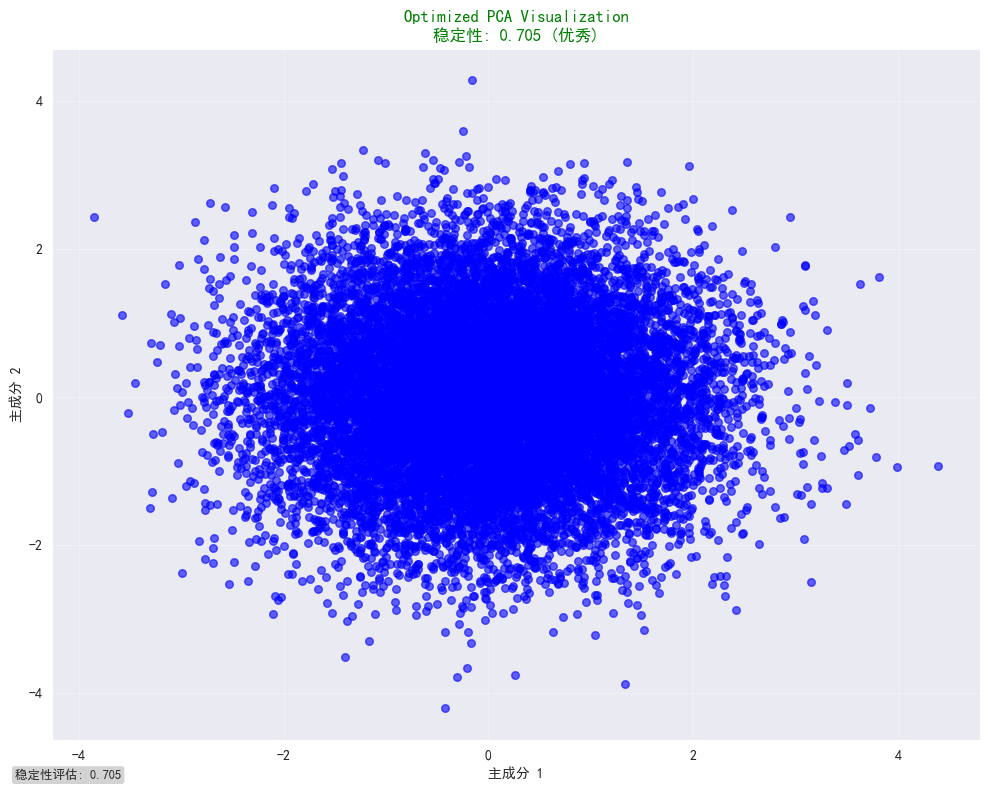

优化PCA可视化已保存: enhanced_pca_visualization.png

=== 最终结果 ===
PCA稳定性得分: 0.7051
✅ PCA改进成功，可视化结果可靠

评估TransE模型性能...
评估结果 - MR: 4084.06, MRR: 0.0818, Hits@1: 0.0148, Hits@3: 0.0896, Hits@10: 0.2559

保存训练好的模型...
模型已保存到 transe_model.pth

=== 生成综合可视化报告 ===

知识图谱应用示例:

查询相似实体: '北柴胡'
错误：查询实体 '北柴胡' 不存在
您是否想查询: 北柴胡(), 银柴胡?

演示加载保存的模型...
模型加载成功!

开始可视化实体嵌入...
开始轻量级可视化流程...
采样后实体数量: 1000
PCA降维完成


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24476\2473900461.py:213: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


已保存: simple_visualization.png
已导出到 embeddings_2d.csv
可视化流程完成


In [6]:
# -------------------- 主函数 --------------------
def main():
    print('===== main() 被调用了 =====')
    import os
    torch.set_num_threads(os.cpu_count())
    print(f"CPU 核数: {os.cpu_count()}，已全开")

    symptom_nodes_path = "d:/Users/LENOVO/Desktop/知识图谱/symptom_mapping_nodes.csv"
    try:
        nodes_for_mapping = pd.read_csv(symptom_nodes_path)
        print(f"✓ 成功加载症状映射节点数据: {len(nodes_for_mapping)} 个节点")
    except Exception as e:
        print(f"❌ 加载症状映射节点数据失败: {str(e)}")
        print("将使用空节点数据进行映射")
        nodes_for_mapping = pd.DataFrame()

    verify_environment()
    device = torch.device('cpu')

    print("加载知识图谱数据...")
    base_path = "d:/Users/LENOVO/Desktop/知识图谱"
    nodes_path = os.path.join(base_path, "clinical_kg_nodes.csv")
    edges_path = os.path.join(base_path, "clinical_kg_edges.csv")

    nodes, edges, triples, node_id_map, node_name_map, rel_id_map = load_kg_data(nodes_path, edges_path)
    if triples is None or len(triples) == 0:
        print("未能加载知识图谱数据，程序终止")
        return

    print(f"知识图谱统计:")
    print(f"- 节点数: {len(node_id_map)}")
    print(f"- 关系类型: {len(rel_id_map)}")
    print(f"- 三元组数: {len(triples)}")

    print("\n进行知识图谱数据增强...")
    enhanced_edges = graph_structure_only_augmentation(nodes, edges, node_id_map)
    print(f"增强后边数: {len(enhanced_edges)} (原边数: {len(edges)})")

    enhanced_triples = []
    for _, row in enhanced_edges.iterrows():
        head = node_id_map.get(row['source_id'])
        tail = node_id_map.get(row['target_id'])
        rel = rel_id_map.get(row['relation_type'])
        if head is not None and tail is not None and rel is not None:
            enhanced_triples.append((head, rel, tail))
    print(f"增强后三元组数: {len(enhanced_triples)}")

    print("\n=== 症状映射调试 ===")
    print(f"节点数据形状: {nodes.shape}")
    print(f"节点列名: {nodes.columns.tolist()}")
    if 'node_type' in nodes.columns:
        symptom_nodes = nodes[nodes['node_type'] == 'symptom']
        print(f"症状节点数量: {len(symptom_nodes)}")
        if len(symptom_nodes) > 0:
            print("症状节点示例:")
            for _, node in symptom_nodes.head(5).iterrows():
                print(f"  - {node.get('node_name', '未知')} (ID: {node['node_id']})")

    common_symptoms = ["头痛", "发热", "咳嗽", "胸闷", "乏力", "食欲不振", "失眠", "心烦"]
    symptom_mapping = enhanced_symptom_mapping(nodes, common_symptoms)
    if len(symptom_mapping) == 0:
        print("\n⚠️ 主要映射失败，尝试备用映射策略...")
        for symptom in common_symptoms:
            for _, node in nodes.iterrows():
                node_name = str(node.get('node_name', ''))
                if symptom in node_name:
                    symptom_mapping[symptom] = node['node_id']
                    print(f"✅ [备用] '{symptom}' -> '{node_name}'")
                    break

    train_triples, test_triples = train_test_split(enhanced_triples, test_size=0.2, random_state=42)
    print(f"- 训练三元组: {len(train_triples)}")
    print(f"- 测试三元组: {len(test_triples)}")

    print("\n进行数据质量分析...")
    comprehensive_data_analysis(nodes, edges, triples, node_id_map)

    print("\n初始化TransE模型...")
    num_entities = len(node_id_map)
    num_relations = len(rel_id_map)
    model = TransE(num_entities, num_relations, embedding_dim=100, norm=2)
    print(f"模型参数: {sum(p.numel() for p in model.parameters()):,}")

    debug_node_mapping(node_name_map, nodes, "北柴胡")

    print("\n开始训练TransE模型...")
    trained_model, loss_history, _ = train_transe_model(
        model, train_triples, device, node_id_map, node_name_map, nodes,
        num_epochs=200, batch_size=512, lr=0.001, margin=5.0
    )
    plot_training_curves(loss_history, None, "training_curves.png")

    print("\n" + "=" * 70)
    print("开始高级功能训练 - 增强注意力GNN和高级强化学习")
    print("=" * 70)
    integrated_framework = None
    try:
        integrated_framework = IntegratedAttentionRLFramework(
            num_entities=num_entities,
            num_relations=num_relations,
            embedding_dim=100
        )
        print("\n--- 开始分阶段训练 ---")
        integrated_framework.phased_training(
            train_triples=train_triples,
            nodes_df=nodes,
            edges_df=edges,
            node_id_map=node_id_map
        )
        print("\n=== 诊断路径优化演示 ===")
        initial_symptoms = ["头痛", "发热"]
        diagnostic_path = integrated_framework.optimize_diagnostic_path(
            initial_symptoms=initial_symptoms,
            nodes_df=nodes,
            edges_df=edges,
            node_id_map=node_id_map,
            max_steps=8
        )
        integrated_framework.save_models(
            "balanced_gnn_model.pth",
            "balanced_rl_agent_model.pth"
        )
        print("\n✅ 平衡框架训练完成!")
        print("\n=== 性能评估 ===")
        self_evaluate_advanced_framework(integrated_framework, nodes, edges, node_id_map, device)
    except Exception as e:
        print(f"平衡框架训练失败: {str(e)}")
        import traceback
        traceback.print_exc()
        print("回退到简化版本...")

    if 'integrated_framework' not in locals() or integrated_framework is None:
        print("❌ 无法创建集成框架，跳过后续演示")
        return

    print("\n=== 开始优势评估 ===")
    advantages = demonstrate_integrated_advantages(
        trained_model,
        integrated_framework.attention_gnn,
        integrated_framework.rl_agent,
        test_triples,
        nodes,
        edges,
        node_id_map,
        node_name_map,
        device
    )
    if advantages:
        print(f"\n✅ 集成框架优势评估完成!")
        print(f"注意力机制改进: {advantages['attention_improvement']:.4f}")
        print(f"强化学习改进: {advantages['rl_improvement']:.1f}%")
        print(f"总体优势: {advantages['overall_advantage']}")
    else:
        print("❌ 优势评估失败")

    integrated_framework.save_models(
        "attention_gnn_model.pth",
        "rl_agent_model.pth"
    )
    print("\n✅ 注意力增强GNN和强化学习功能完成!")

    print("\n开始距离质量验证...")
    test_queries = ["北柴胡", "威灵仙", "脾虚", "湿热", "疼痛", "龙齿颗粒"]
    analyze_similarity_distances(
        trained_model, test_queries, node_id_map, node_name_map, nodes, device
    )

    print("\n" + "=" * 60)
    print("开始药物-证候语义聚类分析")
    print("=" * 60)
    print("\n=== 应用PCA稳健性改进方案 ===")
    entity_embeddings = trained_model.entity_emb.weight.data.cpu().numpy()
    embeddings_2d, best_pca, stability_score = robust_pca_solution(entity_embeddings)
    enhanced_pca_visualization(embeddings_2d, stability_score)
    print(f"\n=== 最终结果 ===")
    print(f"PCA稳定性得分: {stability_score:.4f}")
    if stability_score > 0.7:
        print("✅ PCA改进成功，可视化结果可靠")
    elif stability_score > 0.5:
        print("✅ PCA改进有效，可视化结果基本可靠")
    else:
        print("⚠️ PCA改进有限，建议谨慎解释可视化结果")

    print("\n评估TransE模型性能...")
    mr, mrr, hits1, hits3, hits10 = evaluate_transe_model(trained_model, test_triples, device)

    print("\n保存训练好的模型...")
    model_path = "transe_model.pth"
    torch.save({
        'model_state_dict': trained_model.state_dict(),
        'node_id_map': node_id_map,
        'node_name_map': node_name_map,
        'rel_id_map': rel_id_map,
        'num_entities': num_entities,
        'num_relations': num_relations,
        'embedding_dim': 100
    }, model_path)
    print(f"模型已保存到 {model_path}")

    print("\n=== 生成综合可视化报告 ===")
    print("\n知识图谱应用示例:")
    find_similar_entities_transe(
        trained_model,
        node_id_map,
        node_name_map,
        "北柴胡",
        top_k=5,
        device=device,
        nodes_df=nodes
    )

    print("\n演示加载保存的模型...")
    checkpoint = torch.load(model_path, map_location=device)
    loaded_model = TransE(
        checkpoint['num_entities'],
        checkpoint['num_relations'],
        embedding_dim=checkpoint['embedding_dim']
    )
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.to(device)
    print("模型加载成功!")

    print("\n开始可视化实体嵌入...")
    entity_embeddings = loaded_model.entity_emb.weight.data.cpu().numpy()
    idx_to_entity = {idx: entity_id for entity_id, idx in node_id_map.items()}
    entity_ids = [idx_to_entity[i] for i in range(len(node_id_map))]
    low_resource_visualization(entity_embeddings, entity_ids, nodes)



def debug_node_mapping(node_name_map, nodes_df, query="北柴胡"):
    """调试节点映射"""
    print(f"\n=== 调试节点映射 ===")
    print(f"查询名称: '{query}'")
    print(f"node_name_map 中的键数量: {len(node_name_map)}")
    if query.lower() in node_name_map:
        node_id = node_name_map[query.lower()]
        print(f"找到节点ID: {node_id}")
        node_info = nodes_df[nodes_df['node_id'] == node_id]
        if not node_info.empty:
            print("节点信息:")
            print(node_info.iloc[0])
        else:
            print("在nodes_df中未找到该节点")
    else:
        print(f"在node_name_map中未找到 '{query}'")
        similar = get_close_matches(query.lower(), list(node_name_map.keys()), n=5)
        print(f"最接近的名称: {similar}")

if __name__ == "__main__":
    main()